In [1]:

import os
import matplotlib.pyplot as plt
import torch
import numpy as np


import pyro
import pyro.contrib.gp as gp
import pyro.distributions as dist

from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from pathlib import Path
import sys

# Add the project root to the Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.models.local_stats import GibbsKernel
import matplotlib.pyplot as plt
import pandas as pd

from src.models.parameters import get_all_parameter_interpolants

from typing import Callable

/Users/williambuesnel/anaconda3/envs/FuseProject/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["legend.title_fontsize"] = 16

In [3]:
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float64)

In [4]:
params_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_params.csv"))
ocv_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_ocv.csv"))

interpolants = get_all_parameter_interpolants(params_df, ocv_df, method="clough_tocher")

# X will be just the r0 values, and for now just soc.
# for this, we will also just use the values at 25 deg

x_df = params_df[params_df["Temperature_degC"] == 25]["SOC"].dropna()
y_df = params_df[params_df["Temperature_degC"] == 25]["R0 [Ohm]"].dropna()

# drop the first and last values of x_df and y_df, because they are outliers and will mess up the GP regression. This is because the GP regression is very sensitive to outliers, and we want to test the kernels on the "normal" data.
# x_df = x_df.iloc[1:-1]
# y_df = y_df.iloc[1:-1]

X = torch.tensor(x_df.to_numpy(), dtype=torch.float32)
Y = torch.tensor(y_df.to_numpy(), dtype=torch.float32)

train_X.dtype=torch.float64, train_Y.dtype=torch.float64, test_soc.dtype=torch.float64
tensor(6.7763e-21, grad_fn=<MaxBackward1>)


TypeError: FigureBase.suptitle() missing 1 required positional argument: 't'

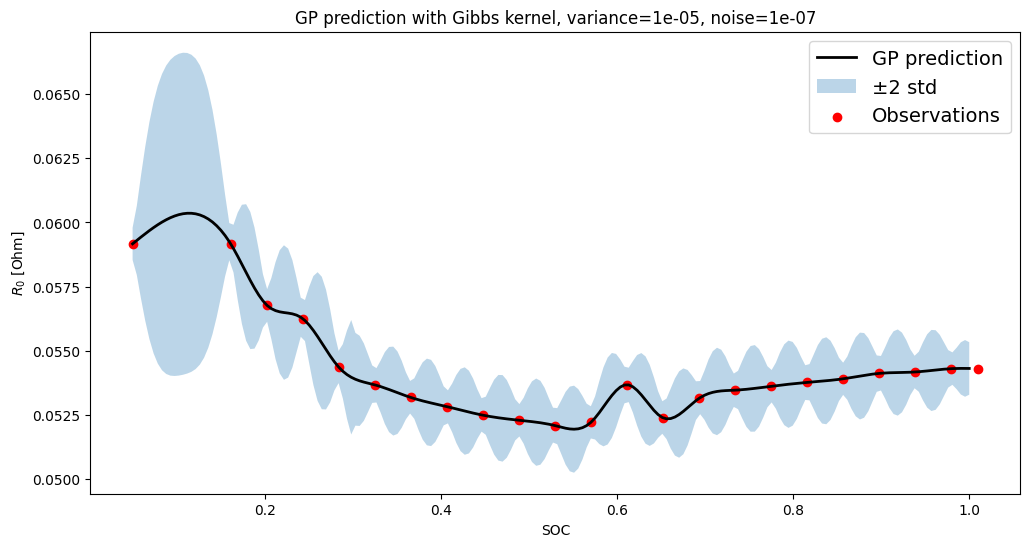

In [5]:
interp_r0 = lambda x: torch.tensor(interpolants["R0 [Ohm]"](x.numpy(), 25.0), dtype=torch.float64)
test_soc = torch.linspace(0.05, 1, 200).reshape(-1, 1)
from pyro.contrib.gp.models import GPRegression
pyro.clear_param_store()

train_X = X.reshape(-1, 1)
train_Y = torch.zeros_like(train_X).reshape(-1)  # Assuming zero mean for the GP prior
# make them all float64 for consistency with the GPRegression model
train_X = train_X.double()
train_Y = train_Y.double()
test_soc = test_soc.double()


def lengthscale_func(soc):
    return 0.025 + 0.005* torch.sigmoid(5000 * (soc - 0.3))

variance = 1e-5
noise = 1e-7

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(variance, dtype=torch.float64))

K_xx = kernel(train_X, train_X)
K_xs = kernel(train_X, test_soc)
K_ss = kernel(test_soc, test_soc)

L = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), K_xs)

posterior_cov = K_ss - K_xs.T @ L
alpha = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), train_Y)

posterior_mean = K_xs.T @ alpha


# check dtypes of train_X, train_Y, test_soc
print(f"{train_X.dtype=}, {train_Y.dtype=}, {test_soc.dtype=}")


mean,cov = posterior_mean, posterior_cov

std = torch.sqrt(torch.diag(cov))

soc = test_soc.squeeze()

ys = interp_r0(test_soc).squeeze(-1) + mean.detach().squeeze()

K = kernel(train_X)
Kinv = torch.linalg.inv(K)

posterior = K - K @ Kinv @ K

print(torch.max(torch.abs(posterior)))


plt.figure(figsize=(12,6))
plt.plot(
    soc,
    ys,
    'k',
    linewidth=2,
    label="GP prediction"
)
plt.fill_between(
    soc,
    (ys - 2*std).detach(),
    (ys + 2*std).detach(),
    alpha=0.3,
    label="±2 std"
)

plt.scatter(
    X.squeeze(),
    Y.squeeze(),
    color="red",
    label="Observations"
)

plt.legend()
plt.xlabel("SOC")
plt.ylabel(r"$R_0$ [Ohm]")
plt.title(f"GP prediction with Gibbs kernel, variance={variance}, noise={noise}")
plt.Figure.suptitle("Gp trained on residuals of Clough-Tocher interpolant of $R_0$ at 25 degC")
#plt.savefig("gp_prediction_gibbs_kernel.pdf", bbox_inches='tight')
plt.show()
plt.cla()
x1 = torch.linspace(0, 1, 100).reshape(-1,1)

K = kernel(x1, x1)

plt.imshow(K.detach())
plt.title("Gibbs Kernel Matrix")
plt.colorbar()
#plt.savefig("gibbs_kernel_matrix.pdf", bbox_inches='tight')
plt.show()


In [ ]:
print("variance:", variance)
print("lengthscale range:", lengthscale_func(test_soc).min(), lengthscale_func(test_soc).max())
print("kernel diag:", torch.diag(kernel(test_soc, test_soc))[:10])
print(f"{kernel.variance=}")

variance: 1e-05
lengthscale range: tensor(0.0250) tensor(0.0300)
kernel diag: tensor([1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05],
       grad_fn=<SliceBackward0>)
kernel.variance=tensor(1.0000e-05, grad_fn=<AddBackward0>)


train_X.dtype=torch.float64, train_Y.dtype=torch.float64, test_soc.dtype=torch.float64
tensor(6.7763e-21, grad_fn=<MaxBackward1>)


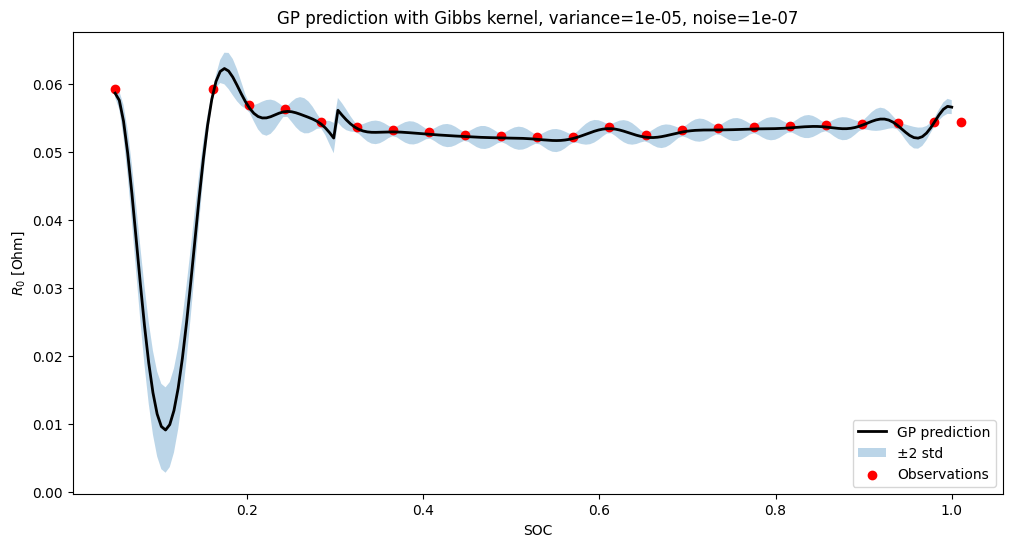

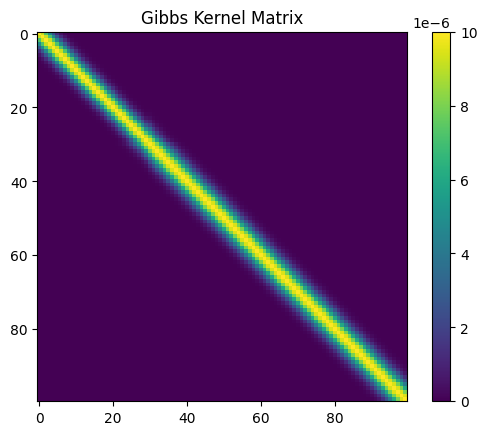

In [ ]:
# test conditioning the kernel on the training data.
 
train_X = X.reshape(-1, 1).double() 
train_Y = Y.reshape(-1, 1).double()


K_xx = kernel(train_X, train_X)
K_xs = kernel(train_X, test_soc)
K_ss = kernel(test_soc, test_soc)

L = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), K_xs)

posterior_cov = K_ss - K_xs.T @ L
alpha = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), train_Y)

posterior_mean = K_xs.T @ alpha


# check dtypes of train_X, train_Y, test_soc
print(f"{train_X.dtype=}, {train_Y.dtype=}, {test_soc.dtype=}")


mean,cov = posterior_mean, posterior_cov

std = torch.sqrt(torch.diag(cov))

soc = test_soc.squeeze()

ys = mean.detach().squeeze()

K = kernel(train_X)
Kinv = torch.linalg.inv(K)

posterior = K - K @ Kinv @ K

print(torch.max(torch.abs(posterior)))


plt.figure(figsize=(12,6))
plt.plot(
    soc,
    ys,
    'k',
    linewidth=2,
    label="GP prediction"
)
plt.fill_between(
    soc,
    (ys - 2*std).detach(),
    (ys + 2*std).detach(),
    alpha=0.3,
    label="±2 std"
)

plt.scatter(
    X.squeeze(),
    Y.squeeze(),
    color="red",
    label="Observations"
)

plt.legend()
plt.xlabel("SOC")
plt.ylabel(r"$R_0$ [Ohm]")
plt.title(f"GP prediction with Gibbs kernel, variance={variance}, noise={noise}")
plt.Figure.suptitle("Gp trained on dataset of $R_0$ at 25 degC")
#plt.savefig("gp_prediction_gibbs_kernel.pdf", bbox_inches='tight')
plt.show()
plt.cla()
x1 = torch.linspace(0, 1, 100).reshape(-1,1)

K = kernel(x1, x1)

plt.imshow(K.detach())
plt.title("Gibbs Kernel Matrix")
plt.colorbar()
#plt.savefig("gibbs_kernel_matrix.pdf", bbox_inches='tight')
plt.show()


In [ ]:
# as expected, sampling the parameter dataset instead of residuals gives an unrealistic shape, due to monotonicity not being preserved here...

In [ ]:
# finally, lets construct a 2d gaussian and visualise it. 
# need to get temp and soc as inputs, and r0 as output.
# for now, will use the same lengthscale function as before, but will need to modify it to take in 2d inputs.
# because temperature (in degrees) is a vastly different scale to SOC, we need to think how to handle this.
def lengthscale_func_2d(x):
    soc = x[:, 0]
    temp = x[:, 1]  # raw temperature, e.g. 5-40
    return 0.025 + 0.005 * torch.sigmoid(5000 * (soc - 0.3)) + 0.5 * temp

train_X_2d = params_df[["SOC", "Temperature_degC"]].dropna().to_numpy()
train_Y_2d_res = np.zeros_like(train_X_2d[:, 0])  # Assuming zero mean for the GP prior
train_X_2d = torch.tensor(train_X_2d, dtype=torch.float64)
train_Y_2d_res = torch.tensor(train_Y_2d_res, dtype=torch.float64)

# build test grid:
soc_range = torch.linspace(train_X_2d[:,0].min(), train_X_2d[:,0].max(), 50)
temp_range = torch.linspace(train_X_2d[:,1].min(), train_X_2d[:,1].max(), 50)
soc_grid, temp_grid = torch.meshgrid(soc_range, temp_range, indexing="ij")

test_X_2d = torch.stack([soc_grid.reshape(-1), temp_grid.reshape(-1)], dim=1).to(torch.float64)


kernel = GibbsKernel(input_dim=2, lengthscale_fn=lengthscale_func_2d, variance=torch.tensor(variance, dtype=torch.float64))

# condition kernel on training data
K_xx = kernel(train_X_2d, train_X_2d)
K_xs = kernel(train_X_2d, test_X_2d)
K_ss = kernel(test_X_2d, test_X_2d)
L = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X_2d)), K_xs)

posterior_cov = K_ss - K_xs.T @ L
alpha = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X_2d)), train_Y_2d_res)

posterior_mean = K_xs.T @ alpha

mean,cov = posterior_mean, posterior_cov

posterior_std = torch.sqrt(torch.diag(cov))

soc = test_X_2d[:, 0].squeeze()
temp = test_X_2d[:, 1].squeeze()

interp_r0 = lambda x,y: torch.tensor(interpolants["R0 [Ohm]"](x.numpy(), y.numpy()), dtype=torch.float64)

ys = interp_r0(soc, temp).squeeze(-1) + mean.detach().squeeze()

print("variance:", variance)
print("lengthscale range:", lengthscale_func_2d(train_X_2d).min(), lengthscale_func_2d(train_X_2d).max())
print("kernel diag:", torch.diag(kernel(train_X_2d, train_X_2d))[:10])

# check all shapes throughout process:

print(f"{train_X_2d.shape=}, {train_Y_2d_res.shape=}, {posterior_mean.shape=}, {posterior_cov.shape=}, {posterior_std.shape=}")
print(f"{mean.shape=}, {cov.shape=}, {ys.shape=}, {soc.shape=}")
print(f"{K_xx.shape=}, {K_xs.shape=}, {K_ss.shape=}, {L.shape=}, {alpha.shape=}")


variance: 1e-05
lengthscale range: tensor(2.5250) tensor(20.0300)
kernel diag: tensor([1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05],
       grad_fn=<SliceBackward0>)
train_X_2d.shape=torch.Size([115, 2]), train_Y_2d_res.shape=torch.Size([115]), posterior_mean.shape=torch.Size([2500]), posterior_cov.shape=torch.Size([2500, 2500]), posterior_std.shape=torch.Size([2500])
mean.shape=torch.Size([2500]), cov.shape=torch.Size([2500, 2500]), ys.shape=torch.Size([2500]), soc.shape=torch.Size([2500])
K_xx.shape=torch.Size([115, 115]), K_xs.shape=torch.Size([115, 2500]), K_ss.shape=torch.Size([2500, 2500]), L.shape=torch.Size([115, 2500]), alpha.shape=torch.Size([115])


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3d projection)

In [ ]:
import plotly.graph_objects as go
import numpy as np

mean_grid = ys.reshape(50, 50).detach().numpy()
std_grid = posterior_std.reshape(50, 50).detach().numpy()
soc_np = soc_grid.numpy()
temp_np = temp_grid.numpy()

fig = go.Figure()

# std surface (uncertainty)
fig.add_trace(go.Surface(
    x=soc_np, y=temp_np, z=mean_grid, surfacecolor=std_grid,
    colorscale="Magma", opacity=0.85, name="GP Posterior Uncertainty",
    colorbar=dict(title="Uncertainty [Ohm]")
))

# training points projected at z=interp_r0(train_X_2d[:, 0], train_X_2d[:, 1]).numpy()
fig.add_trace(go.Scatter3d(
    x=train_X_2d[:, 0].numpy(),
    y=train_X_2d[:, 1].numpy(),
    z=interp_r0(train_X_2d[:, 0], train_X_2d[:, 1]).numpy(),
    mode="markers",
    marker=dict(size=4, color="cyan"),
    name="Training points"
))

fig.update_layout(
    scene=dict(
        xaxis_title="SOC", yaxis_title="Temperature (°C)", zaxis_title="R0 [Ohm]",
        # lock aspect ratio so zoom doesn't distort weirdly
        aspectmode="cube",
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)  # starting zoom/angle
        )
    ),
    title="GP Posterior Uncertainty over Continuous Grid",
    width=900, height=700,
    dragmode="orbit"  # or "turntable" - controls rotation behavior
)

# explicit scroll-zoom + toolbar config
fig.show(config={
    "scrollZoom": True,
    "displayModeBar": True,
    "modeBarButtonsToAdd": ["zoom3d", "pan3d", "resetCameraDefault3d"]
})
lengthscale_desc = "ell(soc, temp) = 0.025 + 0.005·sigmoid(5000·(soc−0.3)) + 0.01·temp_norm"

annotation_text = (
    f"Variance: {variance}<br>"
    f"Noise: {noise}<br>"
    f"Lengthscale fn: {lengthscale_desc}"
)

fig.update_layout(
    annotations=[
        dict(
            text=annotation_text,
            xref="paper", yref="paper",
            x=0.01, y=0.01,          # bottom-left corner
            xanchor="left", yanchor="bottom",
            showarrow=False,
            align="left",
            font=dict(size=12),
            bgcolor="rgba(255,255,255,0.7)",  # slight background so it's readable over the surface
            bordercolor="black",
            borderwidth=1
        )
    ]
)

fig.write_image("gp_uncertainty_plot.pdf", width=1000, height=800, scale=2)
